c:\Program Files\Python39\lib\site-packages\magpy\largeS\LSWT.py:157: ComplexWarning: Casting complex values to real discards the imaginary part
  eigw_sorted[0:zero_block_idx] = zero_eigw
c:\Program Files\Python39\lib\site-packages\magpy\largeS\LSWT.py:159: ComplexWarning: Casting complex values to real discards the imaginary part
  eigw_sorted[zero_block_idx::2] = pos_eigw
c:\Program Files\Python39\lib\site-packages\magpy\largeS\LSWT.py:161: ComplexWarning: Casting complex values to real discards the imaginary part
  eigw_sorted[zero_block_idx+1::2] = neg_eigw


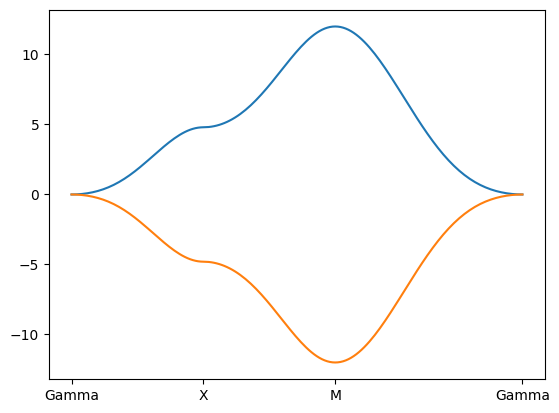

In [4]:
import numpy as np
from magpy.models import Model
from magpy.lattice import SquareLattice
from magpy.interactions import NthNearestNeighborHeisenbergInteraction
from magpy.largeS import LSWT
from magpy.momenta_utils import Momenta
from magpy.plot import LSWT_plot

lattice = SquareLattice()
model = Model(lattice, interactions=[
    NthNearestNeighborHeisenbergInteraction(lattice, n=1, J=-1.0),
    NthNearestNeighborHeisenbergInteraction(lattice, n=2, J=0.1),
], classical_ground_state=3/2 * np.array([[0, 0, 1]]))

momentum_path = \
    lattice.reciprocal_lattice.get_momentum_path_approx_equally_spaced(
        ["Gamma", "X", "M", "Gamma"], 50)

eigws, eigvs = LSWT.get_eigensystems_momentum_space(model, Momenta.of(momentum_path))
LSWT_plot.plot_energies_along_momentum_path(momentum_path, eigws.raw_quantity[0])

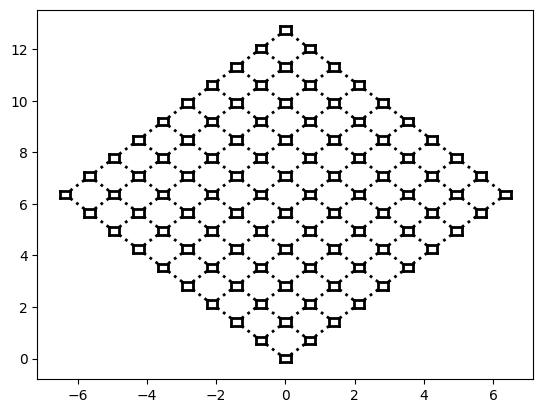

In [1]:
import numpy as np
from magpy.lattice import BravaisLattice

square_side_length = 0.3
octagon_side_length = 1.0

sq_oct_lattice = BravaisLattice(
    bravais_vecs=octagon_side_length/np.sqrt(2) * np.array(
        [[-1, 1], [1, 1]]
    ),
    sublattices=square_side_length/2 * np.array(
        [[1, 1], [-1, 1], [-1, -1], [1, -1]]
    ),
    edges=[
        # square edges
        BravaisLattice.Edge(np.array([0, 0]), np.array([0, 1])),
        BravaisLattice.Edge(np.array([0, 0]), np.array([1, 2])),
        BravaisLattice.Edge(np.array([0, 0]), np.array([2, 3])),
        BravaisLattice.Edge(np.array([0, 0]), np.array([3, 0])),
        # octagon edges
        BravaisLattice.Edge(np.array([1, 0]), np.array([1, 3])),
        BravaisLattice.Edge(np.array([0, 1]), np.array([0, 2])),
    ],
    reciprocal_high_symmetry_points={
        "Gamma": np.array([0, 0]),
        "M": np.array([0.5, 0.5]),
        # ... whatever reciprocal high-symmetry points you like to define
    },
)

from magpy.plot import lattice_plot
lattice_plot.plot_lattice(sq_oct_lattice, (10, 10))


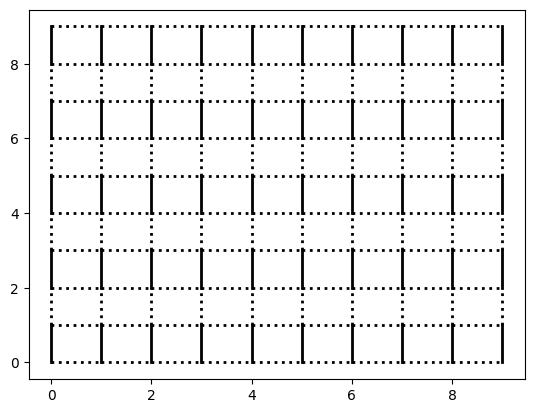

In [1]:
import numpy as np
from magpy.lattice import BravaisLattice
from magpy.models import Model
from magpy.interactions import NthNearestNeighborHeisenbergInteraction

# create square lattice with vertical two-site unit cell
sq_lattice = BravaisLattice(
    bravais_vecs=np.array([[1, 0], [0, 2]]),
    sublattices=np.array([[0, 0], [0, 1]]),
    edges=[
        # intra-unit-cell edge between sublattices 0 and 1
        BravaisLattice.Edge(np.array([0, 0]), np.array([0, 1])),
        # inter-unit-cell edge of sublattice 0 to the right
        BravaisLattice.Edge(np.array([1, 0]), np.array([0, 0])),
        # inter-unit-cell edge of between sublattices 0 and 1 to the top
        BravaisLattice.Edge(np.array([0, 1]), np.array([1, 0])),
        # inter-unit-cell edge of sublattice 1 to the right
        BravaisLattice.Edge(np.array([1, 0]), np.array([1, 1])),
    ],
    reciprocal_high_symmetry_points={},
)
AFM_Heisenberg_model = Model(
    sq_lattice,
    interactions=[
        NthNearestNeighborHeisenbergInteraction(sq_lattice, n=1, J=+1.0),
    ],
    classical_ground_state=1/2 * np.array([[0, 0, 1], [0, 0, -1]])
)

from magpy.plot import lattice_plot
lattice_plot.plot_lattice(sq_lattice, (10, 5))

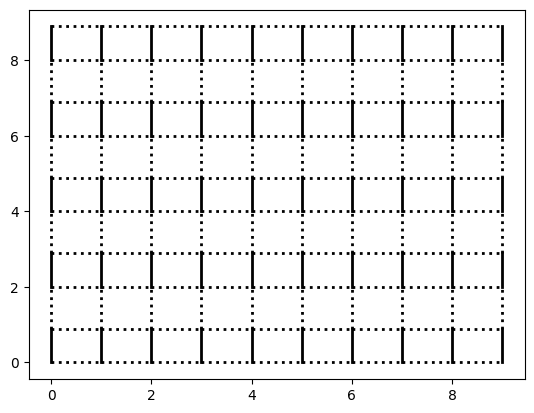

In [2]:
import numpy as np
from magpy.lattice import ChainLattice, BravaisLattice
from magpy.models import Model, stack
from magpy.interactions \
    import HeisenbergInteraction, NthNearestNeighborHeisenbergInteraction

chain_lattice_1d = ChainLattice()
FM_Heisenberg_model_1d = Model(
    chain_lattice_1d,
    interactions=[
        NthNearestNeighborHeisenbergInteraction(chain_lattice_1d, n=1, J=-1.0),
    ],
    classical_ground_state=np.array([[0, 0, 1]])
)

interlayer_edges = [
    BravaisLattice.Edge(np.array([0, 0]), np.array([0, 1])),
    BravaisLattice.Edge(np.array([0, 1]), np.array([1, 0])),
]
layered_Heisenberg_model_2d = stack(
    FM_Heisenberg_model_1d,
    num_layers=2,
    interlayer_edges=interlayer_edges,
    interlayer_interactions=[
        HeisenbergInteraction(edge, J=+1.0) for edge in interlayer_edges
    ],
    additional_high_symmetry_points={
        "X": np.array([0.5, 0]),
        "Y": np.array([0, 0.5]),
        "M": np.array([0.5, 0.5]),
    },
    distance_between_layers=1.0,
    periodic=True,
)

from magpy.plot import lattice_plot
lattice_plot.plot_lattice(layered_Heisenberg_model_2d.lattice, (10, 5))

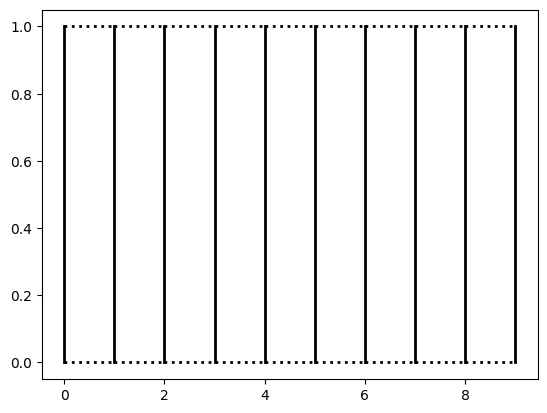

In [1]:
import numpy as np
from magpy.lattice import BravaisLattice
from magpy.models import Model, direct_product
from magpy.interactions import NthNearestNeighborIsingInteraction, \
                               NthNearestNeighborHeisenbergInteraction, \
                               HeisenbergInteraction

# create a chain lattice with embedding space dimension 2 so we can later
# shift the Heisenberg model away from the Ising chain into the second dimension
chain_lattice = BravaisLattice(
    bravais_vecs=np.array([[1, 0]]),
    sublattices=np.array([[0, 0]]),
    edges=[
        BravaisLattice.Edge(np.array([1]), np.array([0, 0]))
    ],
    reciprocal_high_symmetry_points={}
)
FM_Ising_model = Model(
    chain_lattice,
    interactions=[
        NthNearestNeighborIsingInteraction(chain_lattice, n=1, dir="z", J=-1.0),
    ],
    classical_ground_state=np.array([[0, 0, 1]]),
)
FM_Heisenberg_model = Model(
    chain_lattice,
    interactions=[
        NthNearestNeighborHeisenbergInteraction(chain_lattice, n=1, J=-1.0),
    ],
    classical_ground_state=np.array([[0, 0, 1]]),
)

inter_model_edges = [
    BravaisLattice.Edge(np.array([0]), np.array([0, 1])),
]
two_coupled_chains_model = direct_product(
    FM_Ising_model, FM_Heisenberg_model,
    inter_model_edges=inter_model_edges,
    inter_model_interactions=[
        HeisenbergInteraction(edge, J=+0.2) for edge in inter_model_edges
    ],
    sublattice_shifts=np.array([[0, 0], [0, 1]]),
    new_classical_ground_state=np.array([[0, 0, 1], [0, 0, -1]]),
)

from magpy.plot import lattice_plot
lattice_plot.plot_lattice(two_coupled_chains_model.lattice, (10,))

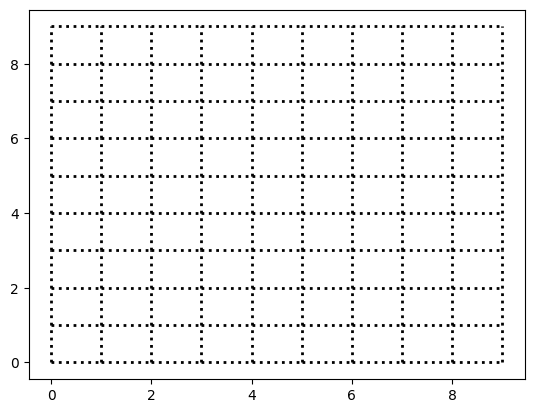

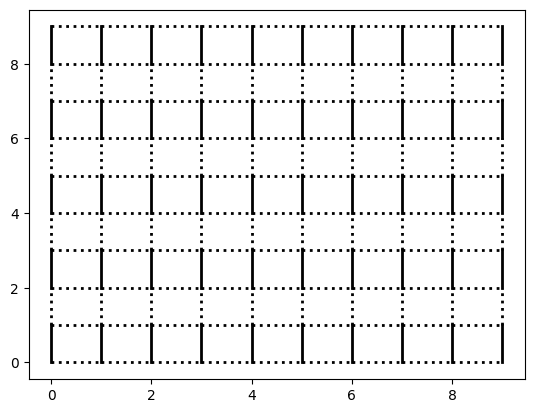

In [2]:
import numpy as np
from magpy.lattice import SquareLattice
from magpy.models import Model, transform
from magpy.interactions import NthNearestNeighborHeisenbergInteraction

sq_lattice = SquareLattice()
AFM_Heisenberg_model = Model(
    sq_lattice,
    interactions=[
        NthNearestNeighborHeisenbergInteraction(sq_lattice, n=1, J=-1.0),
    ],
    # dummy classical ground state
    classical_ground_state=np.array([[0, 0, 1]]),
)

AFM_Heisenberg_model_transformed = transform(
    AFM_Heisenberg_model,
    bravais_trans=np.array([[1, 0], [0, 2]]),
    # (pi, pi) AFM ground state
    new_classical_ground_state=np.array([[0, 0, 1], [0, 0, -1]]),
)

from magpy.plot import lattice_plot
lattice_plot.plot_lattice(AFM_Heisenberg_model.lattice, (10, 10))
lattice_plot.plot_lattice(AFM_Heisenberg_model_transformed.lattice, (10, 5))

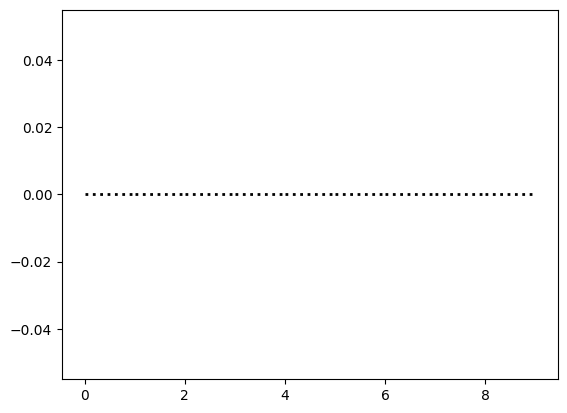

In [4]:
import numpy as np
from magpy.lattice import SquareLattice
from magpy.models import Model, delete_lattice_dimensions
from magpy.interactions import NthNearestNeighborHeisenbergInteraction

sq_lattice = SquareLattice()
FM_Heisenberg_model_2d = Model(
    sq_lattice,
    interactions=[
        NthNearestNeighborHeisenbergInteraction(sq_lattice, n=1, J=-1.0),
    ],
    classical_ground_state=np.array([[0, 0, 1]]),
)

FM_Heisenberg_model_1d = delete_lattice_dimensions(
    FM_Heisenberg_model_2d,
    dims=(1,),
    new_bravais_vecs=np.array([[1, 0]]),
)

from magpy.plot import lattice_plot
lattice_plot.plot_lattice(FM_Heisenberg_model_1d.lattice, (10,))

In [5]:
from magpy.lattice import BravaisLattice
from magpy.interactions import Interaction

XXZ_interaction = Interaction(
    sites=[
        BravaisLattice.Site(np.array([0]), np.array([0])),
        BravaisLattice.Site(np.array([1]), np.array([0])),
    ],
    interaction_tensor=np.array([[-0.5, 0, 0], [-0.5, 0, 0], [0, 0, -1.0]])
)

In [19]:
import numpy as np
from magpy.lattice import HoneycombLatticeA

rec_lattice = HoneycombLatticeA().reciprocal_lattice
sample = rec_lattice.sample_inverse_unit_cell(
    Nks=(10, 10),
    offset="center",
)

assert np.allclose(sample[:, 5, 5], np.zeros(2))
assert np.allclose(sample[:, 0, 1] - sample[:, 0, 0], rec_lattice.reciprocal_vecs[0] / 10)
assert np.allclose(sample[:, 1, 0] - sample[:, 0, 0], rec_lattice.reciprocal_vecs[1] / 10)

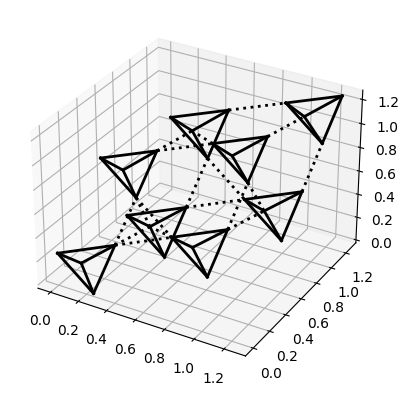

In [8]:
from magpy.lattice import *
from magpy.plot import lattice_plot

lattice_plot.plot_lattice(PyrochloreLattice(), (2, 2, 2))